<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part II · Describing Data &nbsp;|&nbsp; Chapter 9</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Measures of Dispersion <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on how spread out the data is: range and IQR, variance and standard deviation built from scratch, the 68-95-99.7 rule, the box-plot outlier test, and the coefficient of variation.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Same mean, different spread | why the average alone can mislead |
| 2 | Variance &amp; SD from scratch | deviations, squaring, and n vs n−1 |
| 3 | The 68-95-99.7 rule | reading the standard deviation |
| 4 | Box plot &amp; the outlier test | SD vs IQR when an outlier appears |
| 5 | Coefficient of variation | comparing spread across different scales |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(9)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax,t,sub=None):
    ax.set_title(t, loc="left", pad=18)
    if sub: ax.text(0,1.02,sub,transform=ax.transAxes,fontsize=10.5,color=INK_SOFT,va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · WHY SPREAD MATTERS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">⚖️ Same average, very different stories</div>
<div style="color:#4a5578;margin-top:6px">Two classes can share an identical mean score yet be worlds apart. Dispersion is what the mean hides.</div>
</div>

In [2]:
A = pd.Series([70, 72, 75, 78, 80])    # steady class
B = pd.Series([50, 60, 75, 90, 100])   # all over the place
print(f"Class A: mean {A.mean():.0f}, range {A.max()-A.min()}, SD {A.std(ddof=1):.1f}")
print(f"Class B: mean {B.mean():.0f}, range {B.max()-B.min()}, SD {B.std(ddof=1):.1f}")
print("Same mean (75), but B is far more spread out.")

Class A: mean 75, range 10, SD 4.1
Class B: mean 75, range 50, SD 20.6
Same mean (75), but B is far more spread out.


/var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T/ipykernel_57680/837663556.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


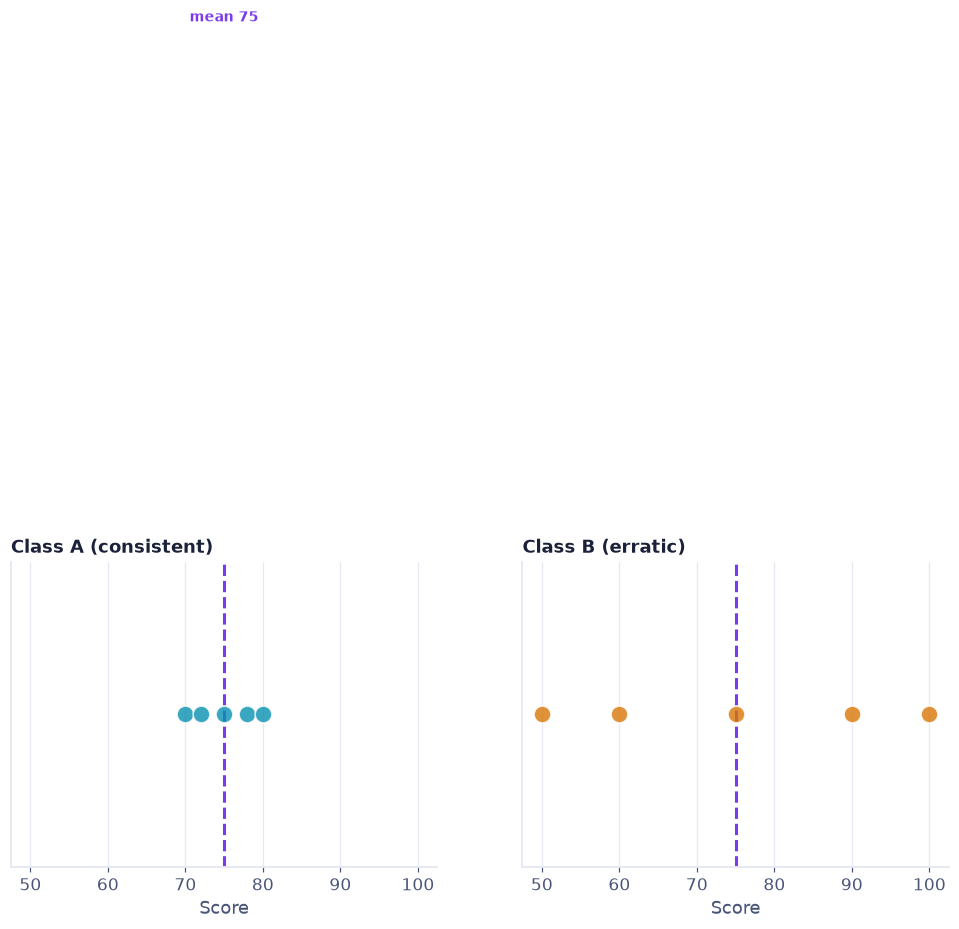

In [3]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,3.6),sharex=True)
for ax,data,name,c in [(a1,A,"Class A (consistent)",CYAN),(a2,B,"Class B (erratic)",AMBER)]:
    ax.scatter(data, [1]*len(data), s=120, color=c, alpha=0.8, edgecolor="white", zorder=3)
    ax.axvline(75, color=PURPLE, ls="--", lw=2)
    ax.set_title(name, loc="left", fontsize=12, fontweight="bold", color=INK)
    ax.set_yticks([]); ax.set_xlabel("Score")
a1.text(75, 1.25, "mean 75", color=PURPLE, ha="center", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · VARIANCE & SD FROM SCRATCH</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📐 Deviations, squared, averaged, rooted</div>
<div style="color:#4a5578;margin-top:6px">Variance averages the squared distances from the mean. Standard deviation square-roots it back into the data's own units.</div>
</div>

In [4]:
x = np.array([4, 8, 6, 5, 7])
mean = x.mean()
dev  = x - mean                 # deviations from the mean (they always sum to 0)
sq   = dev**2                   # square so they do not cancel, and big gaps count more

print("values     :", x)
print("deviations :", dev, " (sum =", dev.sum(), ")")
print("squared    :", sq)
print()
var_pop  = sq.mean()            # divide by n   (whole population)
var_samp = sq.sum()/(len(x)-1)  # divide by n-1 (sample estimate, Bessel's correction)
print(f"Population variance (÷n)   = {var_pop:.2f}   -> SD = {np.sqrt(var_pop):.2f}")
print(f"Sample variance     (÷n-1) = {var_samp:.2f}   -> SD = {np.sqrt(var_samp):.2f}")
print(f"NumPy check: np.std(x, ddof=1) = {np.std(x, ddof=1):.2f}")

values     : [4 8 6 5 7]
deviations : [-2.  2.  0. -1.  1.]  (sum = 0.0 )
squared    : [4. 4. 0. 1. 1.]

Population variance (÷n)   = 2.00   -> SD = 1.41
Sample variance     (÷n-1) = 2.50   -> SD = 1.58
NumPy check: np.std(x, ddof=1) = 1.58


**Why n−1?** The sample mean sits at the center of *its own* sample, so deviations from it run a touch too small. Dividing by the slightly smaller n−1 corrects that downward bias. For large samples the difference is tiny; it matters most when n is small.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · THE 68-95-99.7 RULE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔔 What the standard deviation means</div>
<div style="color:#4a5578;margin-top:6px">For roughly bell-shaped data, about 68% of values fall within 1 SD of the mean, 95% within 2, and 99.7% within 3. The SD becomes a ruler for "how unusual is this?"</div>
</div>

In [5]:
data = rng.normal(100, 15, 100_000)   # mean 100, SD 15 (like IQ scores)
mu, sd = data.mean(), data.std()
for k in (1, 2, 3):
    pct = np.mean(np.abs(data-mu) < k*sd) * 100
    cheb = (1 - 1/k**2) * 100 if k>1 else 0
    print(f"within {k} SD: {pct:4.1f}%  (empirical-rule target ~{[68,95,99.7][k-1]}%, Chebyshev floor ≥{cheb:.0f}%)")

within 1 SD: 68.2%  (empirical-rule target ~68%, Chebyshev floor ≥0%)
within 2 SD: 95.4%  (empirical-rule target ~95%, Chebyshev floor ≥75%)
within 3 SD: 99.7%  (empirical-rule target ~99.7%, Chebyshev floor ≥89%)


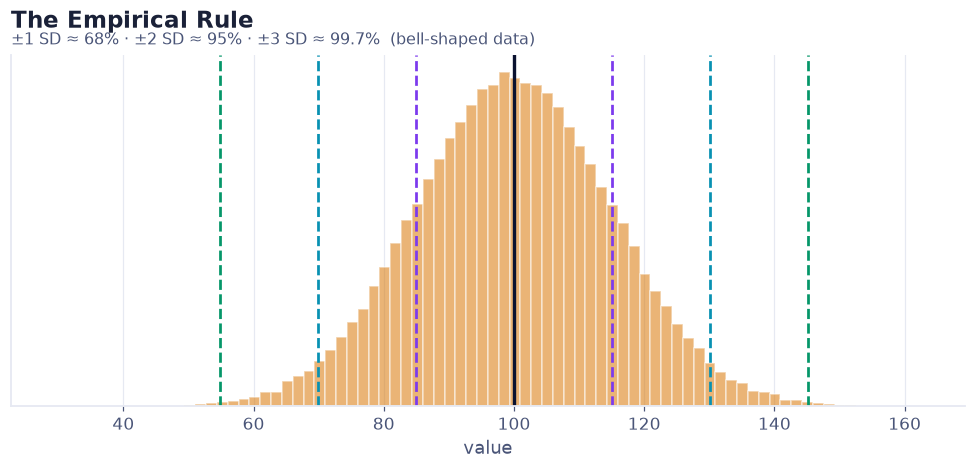

In [6]:
fig,ax=plt.subplots(figsize=(9,4.4))
ax.hist(data, bins=80, color=AMBER, alpha=0.55, edgecolor="white")
for k,c in [(1,PURPLE),(2,CYAN),(3,GREEN)]:
    ax.axvline(mu-k*sd, color=c, ls="--", lw=1.8)
    ax.axvline(mu+k*sd, color=c, ls="--", lw=1.8)
ax.axvline(mu, color=NAVY, lw=2.2)
titlecard(ax,"The Empirical Rule","±1 SD ≈ 68% · ±2 SD ≈ 95% · ±3 SD ≈ 99.7%  (bell-shaped data)")
ax.set_xlabel("value"); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Chebyshev's bonus:** even for *any* shape of data (not just bell curves), at least 75% of values lie within 2 SD and at least 89% within 3 SD. Weaker guarantees, but they always hold. And **z = (x − mean) / SD** tells you how many SDs from the mean a value sits, the idea behind the z-score we use later.

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · THE OUTLIER TEST</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📦 Box plots, and SD vs IQR</div>
<div style="color:#4a5578;margin-top:6px">The box plot draws the five-number summary and flags outliers beyond 1.5×IQR. Watch how one outlier balloons the SD while the IQR barely moves.</div>
</div>

In [7]:
salaries = pd.Series([42, 45, 48, 50, 47, 44, 46])      # $k
with_ceo = pd.concat([salaries, pd.Series([1000])], ignore_index=True)

def iqr(s): return s.quantile(.75) - s.quantile(.25)
print(f"Team only : SD {salaries.std(ddof=1):6.1f},  IQR {iqr(salaries):.1f}")
print(f"+ the CEO : SD {with_ceo.std(ddof=1):6.1f},  IQR {iqr(with_ceo):.1f}")
print("The SD exploded; the IQR hardly noticed. IQR is the robust choice.")

Team only : SD    2.6,  IQR 3.0
+ the CEO : SD  337.3,  IQR 3.8
The SD exploded; the IQR hardly noticed. IQR is the robust choice.


/var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T/ipykernel_57680/232717059.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp=ax.boxplot([salaries, with_ceo], vert=False, patch_artist=True, widths=0.5,


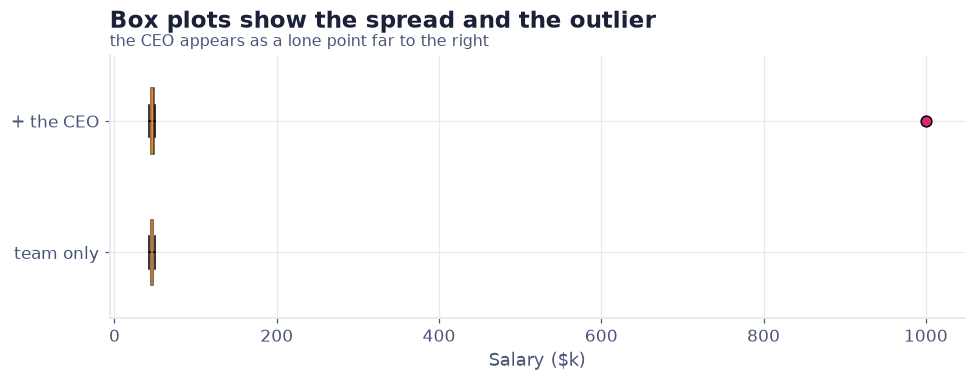

In [8]:
fig,ax=plt.subplots(figsize=(9,3.6))
bp=ax.boxplot([salaries, with_ceo], vert=False, patch_artist=True, widths=0.5,
              flierprops=dict(marker="o", markerfacecolor=PINK, markersize=7))
for patch,c in zip(bp["boxes"],[CYAN,AMBER]): patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_yticks([1,2]); ax.set_yticklabels(["team only","+ the CEO"])
titlecard(ax,"Box plots show the spread and the outlier","the CEO appears as a lone point far to the right")
ax.set_xlabel("Salary ($k)")
plt.tight_layout(); plt.show()

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · COEFFICIENT OF VARIATION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Comparing spread across different scales</div>
<div style="color:#4a5578;margin-top:6px">Is height more variable than weight? They use different units, so raw SD can't be compared. The coefficient of variation (CV = SD / mean) is unitless, so it can.</div>
</div>

In [9]:
heights = rng.normal(170, 7,  500)    # cm
weights = rng.normal(70, 12,  500)    # kg

for name, s in [("Height (cm)", heights), ("Weight (kg)", weights)]:
    cv = s.std(ddof=1) / s.mean() * 100
    print(f"{name:<12}: mean {s.mean():6.1f}, SD {s.std(ddof=1):5.1f}, CV {cv:5.1f}%")
print("\nWeight has the larger CV, so it is RELATIVELY more variable, even though the numbers look smaller.")
print("Caution: CV only makes sense for positive data on a ratio scale (a true zero).")

Height (cm) : mean  169.7, SD   6.9, CV   4.1%
Weight (kg) : mean   70.1, SD  12.0, CV  17.1%

Weight has the larger CV, so it is RELATIVELY more variable, even though the numbers look smaller.
Caution: CV only makes sense for positive data on a ratio scale (a true zero).


---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Dispersion</b> tells you what the mean hides: how spread out the data is.</li>
<li><b>Range</b> and <b>IQR</b> are quick; IQR (and the box plot) resist outliers.</li>
<li><b>Variance</b> averages squared deviations; <b>SD</b> roots it back into real units. Use n−1 for a sample.</li>
<li>For bell-shaped data the <b>68-95-99.7 rule</b> turns SD into a ruler; Chebyshev gives looser limits for any shape.</li>
<li><b>CV</b> compares relative spread across different units, when the data is positive with a true zero.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>